# Carousel Lens Modeling - model2

Strong lensing model using GIGA-Lens.
Uses TFP distributions directly with JointDistributionSequential.

## Imports

In [10]:
import time
import json
from datetime import datetime

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles import mass, light

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt

from astropy.io import fits
from astropy.visualization import simple_norm
from corner import corner

tfd = tfp.distributions
print("Imports successful")

Imports successful


## Utility Functions

In [11]:
def load_result(d):
    """Convert nested dict with lists to nested dict with jnp arrays"""
    new_d = {}
    for k, v in d.items():
        if isinstance(v, list):
            new_d[k] = jnp.squeeze(jnp.array(v))
        elif isinstance(v, dict):
            new_d[k] = load_result(v)
        else:
            new_d[k] = v
    return new_d

## Load Data

In [12]:
# Load image and PSF
with fits.open('f140w_img.fits') as hdul:
    observed_img = hdul[0].data.astype(np.float32)
    exp_time = hdul[0].header.get('EXPTIME', 600.0)

psf = np.load('psf.npy').astype(np.float32)
psf = psf / psf.sum()  # Normalize

# For simplified carousel-lens, use no binning (binning=1)
binning = 1

print(f"Image shape: {observed_img.shape}")
print(f"PSF shape: {psf.shape}")
print(f"PSF sum: {psf.sum():.8f}")
print(f"Exposure time: {exp_time}")

# Background and exposure
bkg_rms = 0.0076
exp_time_use = exp_time

# Use full image (no cutout, no modifications)
img_no_s7 = observed_img.copy()

print(f"Using image: {img_no_s7.shape}")

Image shape: (800, 800)
PSF shape: (27, 27)
PSF sum: 1.00000000
Exposure time: 597.694383
Using image: (800, 800)


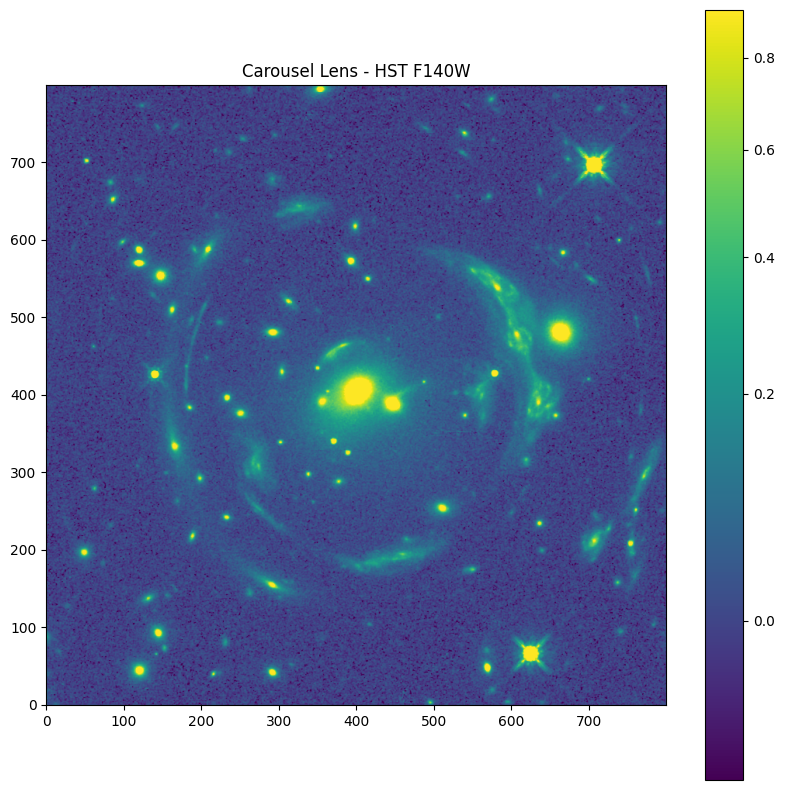

In [13]:
# Visualize
norm = simple_norm(observed_img, 'sqrt', percent=99.)
plt.figure(figsize=(10, 10))
plt.imshow(observed_img, norm=norm, cmap='viridis', origin='lower')
plt.title('Carousel Lens - HST F140W')
plt.colorbar()
plt.show()

## Define Priors Using TFP Distributions

In [14]:
# Build joint prior using TFD - matching sean's distributions

# Lens mass prior
lens_mass_prior = tfd.JointDistributionSequential([
    # Main lens (EPL)
    tfd.JointDistributionNamed(dict(
        theta_E=tfd.Uniform(0.5, 3.0),
        gamma=tfd.Uniform(1.0, 3.0),
        e1=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        e2=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        center_x=tfd.Normal(0, 0.3),
        center_y=tfd.Normal(0, 0.3),
    )),
    # External shear
    tfd.JointDistributionNamed(dict(
        gamma1=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        gamma2=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
    )),
])

print("✓ Lens mass prior defined")

✓ Lens mass prior defined


In [15]:
# Lens light prior (2 components - cluster galaxies)
lens_light_prior = tfd.JointDistributionSequential([
    # Component 1
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(1.0), 0.3),
        n_sersic=tfd.Uniform(2.0, 6.0),
        e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        center_x=tfd.Normal(0, 0.1),
        center_y=tfd.Normal(0, 0.1),
        Ie=tfd.LogNormal(jnp.log(30), 0.5),
    )),
    # Component 2
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(1.0), 0.3),
        n_sersic=tfd.Uniform(4.0, 8.0),
        e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        center_x=tfd.Normal(0, 0.1),
        center_y=tfd.Normal(0, 0.1),
        Ie=tfd.LogNormal(jnp.log(30), 0.5),
    )),
])

print("✓ Lens light prior defined")

✓ Lens light prior defined


In [16]:
# Source light prior (2 components - extended sources)
source_light_prior = tfd.JointDistributionSequential([
    # Component 1
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(0.25), 0.2),
        n_sersic=tfd.Uniform(0.5, 4.0),
        e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        center_x=tfd.Normal(-0.2, 0.3),
        center_y=tfd.Normal(-0.2, 0.3),
        Ie=tfd.LogNormal(jnp.log(20), 0.5),
    )),
    # Component 2
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(0.25), 0.2),
        n_sersic=tfd.Uniform(0.5, 4.0),
        e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        center_x=tfd.Normal(0.2, 0.3),
        center_y=tfd.Normal(0.2, 0.3),
        Ie=tfd.LogNormal(jnp.log(20), 0.5),
    )),
])

print("✓ Source light prior defined")

✓ Source light prior defined


In [17]:
# Verify all priors created
test_sample = lens_mass_prior.sample(seed=jax.random.PRNGKey(0))
print("✓ All priors verified and ready")

✓ All priors verified and ready


## Combine Priors and Create Physical Model

In [18]:
# Combine all priors into joint prior
joint_prior = tfd.JointDistributionSequential([
    lens_mass_prior,
    lens_light_prior,
    source_light_prior,
])

# Physical model - same structure for all systems
phys_model = PhysicalModel(
    lenses=[mass.epl.EPL(), mass.shear.Shear()],
    lens_light=[light.sersic.SersicEllipse(use_lstsq=False), 
                light.sersic.SersicEllipse(use_lstsq=False)],
    source_light=[light.sersic.SersicEllipse(use_lstsq=False),
                  light.sersic.SersicEllipse(use_lstsq=False)],
)

print("✓ Joint prior and physical model created")

✓ Joint prior and physical model created


## Setup Simulator Config

In [19]:
# Simulator config - EXACTLY matching sean's pattern
pix_scale = 0.065
num_pix = img_no_s7.shape[0]

sim_config = SimulatorConfig(
    delta_pix=pix_scale,
    num_pix=num_pix,
    kernel=psf,
)

print(f"SimulatorConfig: delta_pix={pix_scale}, num_pix={num_pix}, kernel shape={psf.shape}")

SimulatorConfig: delta_pix=0.065, num_pix=800, kernel shape=(27, 27)


## Create Probabilistic Model

In [20]:
# Probabilistic model
prob_model = ForwardProbModel(
    joint_prior,
    img_no_s7,
    background_rms=bkg_rms,
    exp_time=exp_time_use,
)

# Modeling sequence
model_seq = ModellingSequence(
    phys_model,
    prob_model,
    sim_config,
)

print("✓ Probabilistic model and ModellingSequence created")

✓ Probabilistic model and ModellingSequence created


## Generate Starting Points

In [21]:
# Generate starting points from prior
start = joint_prior.sample(100, jax.random.PRNGKey(42))

print(f"✓ Generated 100 starting points from joint prior")

✓ Generated 100 starting points from joint prior


## MAP Optimization

In [22]:
# Setup optimizer - EXACTLY matching sean's
num_steps = 5000

schedule_fn = optax.polynomial_schedule(
    init_value=1e-4,
    end_value=1e-6,
    power=0.5,
    transition_steps=num_steps,
)
opt = optax.adabelief(schedule_fn, b1=0.95, b2=0.99)

print(f"Optimizer: adabelief, schedule 1e-4→1e-6, {num_steps} steps")

Optimizer: adabelief, schedule 1e-4→1e-6, 5000 steps


In [ ]:
# Run MAP - EXACTLY like sean
t = time.time()
print(datetime.now())
print("Starting MAP...")

from jax.experimental import shard_map
best, lps, chisq = model_seq.MAP(optimizer=opt, n_samples=100, num_steps=num_steps, start=start, seed=0)

t_sample = time.time() - t
print(f"MAP complete! Time: {t_sample / 60:.1f} min")
print(f"Best χ²: {chisq[-1]:.4f}")
print(f"Best log prob: {lps[-1]:.4f}")

np.save('MAP.npy', best)

2026-04-10 02:13:13.296081
Starting MAP...


  0%|          | 0/5000 [00:11<?, ?it/s]2026-04-10 02:13:41.287765: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv %cudnn-conv-bias-activation = (f32[100,1,800,800]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.55, %constant.9970, %constant.10076), window={size=27x27 pad=13_13x13_13}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_name="jit(run_map)/jit(main)/jit(shmap_body)/while/body/jit(loss)/jvp(jit(log_prob))/jit(simulate)/conv_general_dilated" source_file="/tmp/ipykernel_392211/811609741.py" source_line=7}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":0.0042249998077750206,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-04-10 02:13:42.183628: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation t

## Visualize

In [ ]:
# Plot optimization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(chisq)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('χ²')
ax1.set_title('Chi-squared')
ax1.grid()

ax2.plot(lps)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Log Prob')
ax2.set_title('Log Probability')
ax2.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Simulate best model
simulator = LensSimulator(phys_model, sim_config, bs=1)
simulated = simulator.simulate(prob_model.bij.forward(best.T.tolist()))

plt.figure(figsize=(22, 6))

plt.subplot(131)
plt.imshow(img_no_s7, norm=plt.matplotlib.colors.PowerNorm(0.5, vmin=0, vmax=1.5), origin="lower")
plt.colorbar()
plt.title('Observed')
plt.axis('off')

plt.subplot(132)
plt.imshow(simulated, norm=plt.matplotlib.colors.PowerNorm(0.5, vmin=0, vmax=1.5), origin="lower")
plt.colorbar()
plt.title('Model')
plt.axis('off')

plt.subplot(133)
resid = img_no_s7 - simulated
err_map = np.sqrt(simulated / exp_time_use + bkg_rms**2)
plt.imshow(resid/err_map, cmap='coolwarm', interpolation='none', vmin=-4, vmax=4, origin="lower")
plt.colorbar()
plt.title(f'Residuals (χ²={chisq[-1]:.1f})')
plt.axis('off')

plt.tight_layout()
plt.show()